In [72]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [71]:
# 1. 데이터 불러오기
df = pd.read_csv('전북_지역별_통합_교통량(수도권).csv')

# 2. 양방향 교통량 합계 컬럼 생성
# 도착지방향과 출발지방향 총교통량을 더해 '전체교통량' 컬럼을 만듭니다.
df['전체교통량'] = df['도착지방향총교통량'] + df['출발지방향총교통량']

# 3. 출발지역별로 합계 계산
# 이제 기준을 '전체교통량'으로 잡습니다.
departure_traffic = df.groupby('출발지역')[['출발지방향총교통량','도착지방향총교통량','전체교통량']].sum().reset_index()

# 4. 교통량이 적은 순(오름차순)으로 정렬
departure_traffic_sorted = departure_traffic.sort_values(by='전체교통량', ascending=True)

# 5. 결과 출력
print("\n[양방향 합산 교통량]")
print(departure_traffic_sorted)
summary_df.to_csv('전북_수도권_교통량_통계.csv', index=False, encoding='utf-8-sig')
# summary_df = departure_traffic_sorted

# summary_df['전체 교통량'] = summary_df['출발지방향총교통량'] + summary_df['도착지방향총교통량']

# # 4. 컬럼명 변경 (요청하신 형식에 맞춰 직관적으로 변경)
# summary_df.columns = ['지역', '출발지방향 총합', '도착지방향 총합', '전체 교통량']

# # 5. 교통량이 많은 순서대로 정렬 (선택 사항)
# summary_df = summary_df.sort_values(by='전체 교통량', ascending=False)

# # 6. CSV 파일로 저장
# # 인코딩은 한글 깨짐 방지를 위해 'utf-8-sig'를 권장합니다.
# summary_df.to_csv('전북_수도권_교통량_통계.csv', index=False, encoding='utf-8-sig')

# # 7. 결과 확인
# print("CSV 파일 생성이 완료되었습니다!")
# print(summary_df.head())



[양방향 합산 교통량]
   출발지역  출발지방향총교통량  도착지방향총교통량  전체교통량
6    순창          2          4      6
12   진안          4          5      9
3    남원         17         16     33
0    고창         32         31     63
8    임실         41         34     75
2    김제         40         41     81
5    부안         50         75    125
11   정읍         63         62    125
9    장수         71         67    138
7    익산        151        115    266
1    군산        105        209    314
4    무주        180        174    354
10   전주        238        234    472


In [62]:
# 1. 데이터 불러오기
df = pd.read_csv('전북_거점별_통합_교통량_최종(충북).csv')

# 2. 양방향 교통량 합계 컬럼 생성
# 도착지방향과 출발지방향 총교통량을 더해 '전체교통량' 컬럼을 만듭니다.
df['전체교통량'] = df['도착지방향_교통량합계'] + df['출발지방향_교통량합계']

# 3. 출발지역별로 합계 계산
# 이제 기준을 '전체교통량'으로 잡습니다.
departure_traffic = df.groupby('출발지역')['전체교통량'].sum().reset_index()

# 4. 교통량이 적은 순(오름차순)으로 정렬
departure_traffic_sorted = departure_traffic.sort_values(by='전체교통량', ascending=True)

# 5. 결과 출력
print("\n[양방향 합산 교통량]")
print(departure_traffic_sorted)


[양방향 합산 교통량]
   출발지역  전체교통량
6    순창     10
0    고창     19
12   진안     20
5    부안     21
9    장수     51
1    군산     54
3    남원     54
8    임실    160
2    김제    203
4    무주    203
11   정읍    281
7    익산   1194
10   전주   1681


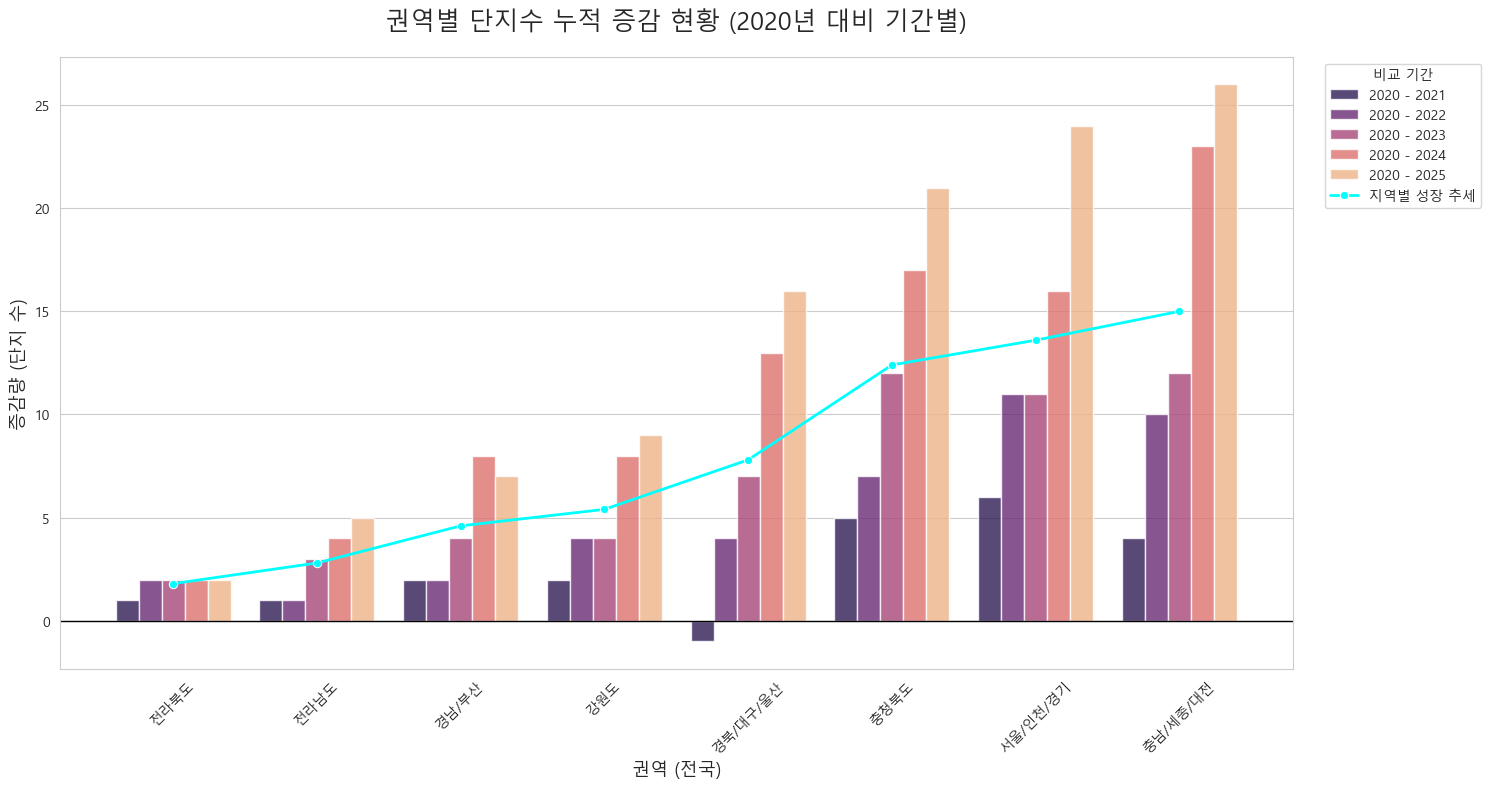

In [91]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
df = pd.read_csv('권역별_단지수_통합현황.csv')
df_indexed = df.set_index('전국') # 전국을 인덱스로 정함

# 2. 기간별 증감치 계산 (예: 2020-2021, 2020-2022 ...)
years = ['2021년', '2022년', '2023년', '2024년', '2025년'] # 계산할 연도
diff_data = {} # 딕셔너리

for year in years:
    label = f"2020 - {year.replace('년', '')}" # '2020 - 2021' 형식 생성
    diff_data[label] = df_indexed[year] - df_indexed['2020년'] # 증감 계산

diff_df = pd.DataFrame(diff_data) # 데이터프레임 변환

# 3. 정렬 로직 (마지막 기간인 '2020-2025' 증감치 기준 내림차순)
last_period = diff_df.columns[-1]
sorted_regions = diff_df.sort_values(by=last_period, ascending=False).index.tolist()

# 시각화를 위한 데이터 재구성
plot_df = diff_df.reset_index().melt(id_vars='전국', var_name='기간', value_name='증감치')

# 4. 그래프 그리기
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")
plt.rc('font', family='Malgun Gothic')

# [막대 그래프] x축: 전국, 구분(hue): 기간
sns.barplot(
    data=plot_df, 
    x='전국', 
    y='증감치', 
    hue='기간', 
    palette='magma', 
    alpha=0.8,
    order=sorted_regions
)

# [선 그래프] 지역별 평균 추세선 (막대 중앙 관통)
sns.lineplot(
    data=plot_df, 
    x='전국', 
    y='증감치', 
    color='cyan', 
    marker='o', 
    linewidth=2, 
    label='지역별 성장 추세',
    errorbar=None,
    sort=True
)

# 5. 그래프 세부 설정
plt.title('권역별 단지수 누적 증감 현황 (2020년 대비 기간별)', fontsize=18, pad=20)
plt.xlabel('권역 (전국)', fontsize=13)
plt.ylabel('증감량 (단지 수)', fontsize=13)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=1)

plt.legend(title='비교 기간', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()